# 03 · MQAR: recall, capacity, interference, and the δ × CG surface

Multi-query associative recall (MQAR) is the memory task where MesaNet's exact "fit all of history" solve is supposed to pay off. Three experiments:

- A · Capacity: recall vs how many key→value pairs you store (n_pairs), plus a control that separates "state full" from "forgot the early ones."
- B · Distractors: recall when extra never-asked pairs compete for the memory, and what the forget gate does under that interference.
- C · δ × CG: the joint surface of Mesa's two knobs (how much it keeps, and how hard it solves).

Each section trains its own models and stands alone; the data is shown inline below. (This merges the former notebooks 03, 04, and 05.)

In [1]:
%matplotlib inline
import sys, os, math
sys.path.insert(0, os.path.abspath(".."))  # project root: makes `compare` importable

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from synthtasks.mqar import make_mqar
from compare.profile import mixer_flops_per_token
from compare.experiments import (
    MQARConfig, train_mqar, train_mqar_models, mqar_sweep_rows, mqar_cg_rows,
    mqar_position_rows, mqar_flops_note, benchmark_mqar_latency, plot_mse_vs, plot_capacity_forget_control,
    mqar_delta_cg_sweep, plot_delta_cg_heatmap,
)

np.set_printoptions(precision=3, suppress=True)
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
def show(rows, x, ykey="acc"):
    """Compact accuracy table: one row per model label, columns = the swept axis `x`."""
    labels = []
    for r in rows:
        if r["label"] not in labels:
            labels.append(r["label"])
    xs = sorted({r[x] for r in rows if r.get(x) is not None})
    print(f"{x:>16}  " + "  ".join(f"{v:>6}" for v in xs))
    for lb in labels:
        dd = {r[x]: r[ykey] for r in rows if r["label"] == lb and r.get(x) is not None}
        body = "  ".join((f"{dd[v]:6.3f}" if v in dd else "    --") for v in xs)
        print(f"{lb:>16}  {body}")

## MQAR data: what the model sees

Three quick looks at the generator (no model): a small write→query→answer sample, the same with a heavy memory load (large n_pairs), and one with distractors (extra pairs that are never asked about).

In [3]:
n_pairs, n_queries, gap, vocab = 4, 3, 3, 12
mq_in, mq_tg, mq_mask = make_mqar(
    batch=4, n_pairs=n_pairs, n_queries=n_queries, gap=gap, vocab=vocab, seed=SEED)

print(f"inputs {mq_in.shape}  targets {mq_tg.shape}  mask {mq_mask.shape}   (id 0 = blank filler)")
print("\nExample 0:")
print("  tokens :", mq_in[0].tolist())
print("  target :", mq_tg[0].tolist())
print("  mask   :", mq_mask[0].astype(int).tolist())
bindings = {int(mq_in[0, 2*i]): int(mq_in[0, 2*i+1]) for i in range(n_pairs)}
print("\n  writes (key -> value):", bindings)
for p in np.where(mq_mask[0])[0]:
    print(f"  query @pos {p:2d}: key {int(mq_in[0, p])} -> expected value {int(mq_tg[0, p])}")

inputs (4, 14)  targets (4, 14)  mask (4, 14)   (id 0 = blank filler)

Example 0:
  tokens : [3, 1, 10, 2, 7, 9, 6, 8, 0, 0, 0, 6, 7, 7]
  target : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 9, 9]
  mask   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]

  writes (key -> value): {3: 1, 10: 2, 7: 9, 6: 8}
  query @pos 11: key 6 -> expected value 8
  query @pos 12: key 7 -> expected value 9
  query @pos 13: key 7 -> expected value 9


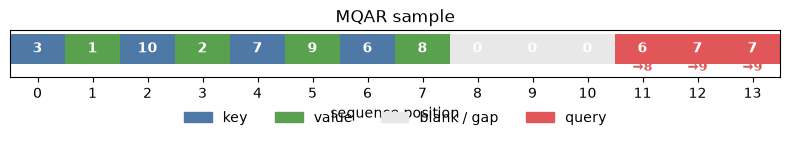

In [4]:
L = mq_in.shape[1]
q_start = 2 * n_pairs + gap

role = np.zeros(L, dtype=int)          # 0 blank, 1 key, 2 value, 3 query
role[0:2 * n_pairs:2] = 1
role[1:2 * n_pairs:2] = 2
role[q_start:q_start + n_queries] = 3

cmap = ListedColormap(["#e8e8e8", "#4e79a7", "#59a14f", "#e15759"])
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 2.0))
ax.imshow(role[None, :], aspect="auto", cmap=cmap, norm=norm)
for t in range(L):
    ax.text(t, 0, str(int(mq_in[0, t])), ha="center", va="center",
            color="white", fontweight="bold")
    if mq_mask[0, t]:
        ax.text(t, 0.62, f"\u2192{int(mq_tg[0, t])}", ha="center", va="center",
                color="#e15759", fontsize=9, fontweight="bold")
ax.set_ylim(0.95, -0.6)
ax.set_yticks([])
ax.set_xticks(range(L))
ax.set_xlabel("sequence position")
ax.set_title("MQAR sample")
handles = [Patch(color="#4e79a7", label="key"), Patch(color="#59a14f", label="value"),
           Patch(color="#e8e8e8", label="blank / gap"), Patch(color="#e15759", label="query")]
ax.legend(handles=handles, ncol=4, loc="upper center",
          bbox_to_anchor=(0.5, -0.45), frameon=False)
plt.tight_layout()
plt.savefig("figures/03_mqar_data.png", dpi=600, bbox_inches="tight"); plt.show()

inputs (4, 42)   write block = 32 tokens (16 bindings), gap = 6, queries = 4  ->  L = 42


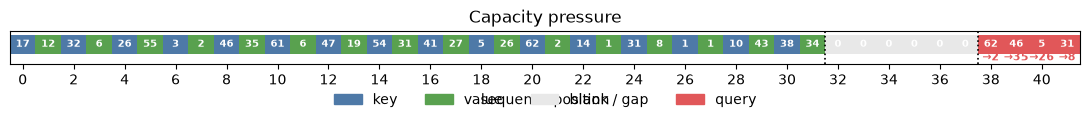

In [5]:
big_pairs, big_queries, big_gap, big_vocab = 16, 4, 6, 64
bg_in, bg_tg, bg_mask = make_mqar(
    batch=4, n_pairs=big_pairs, n_queries=big_queries, gap=big_gap, vocab=big_vocab, seed=SEED)
Lb = bg_in.shape[1]
qb_start = 2 * big_pairs + big_gap
print(f"inputs {bg_in.shape}   write block = {2*big_pairs} tokens ({big_pairs} bindings), "
      f"gap = {big_gap}, queries = {big_queries}  ->  L = {Lb}")

role = np.zeros(Lb, dtype=int)             # 0 blank, 1 key, 2 value, 3 query
role[0:2 * big_pairs:2] = 1
role[1:2 * big_pairs:2] = 2
role[qb_start:qb_start + big_queries] = 3

cmap = ListedColormap(["#e8e8e8", "#4e79a7", "#59a14f", "#e15759"])
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(11, 1.9))
ax.imshow(role[None, :], aspect="auto", cmap=cmap, norm=norm)
for t in range(Lb):
    ax.text(t, 0, str(int(bg_in[0, t])), ha="center", va="center",
            color="white", fontsize=7, fontweight="bold")
    if bg_mask[0, t]:
        ax.text(t, 0.7, f"→{int(bg_tg[0, t])}", ha="center", va="center",
                color="#e15759", fontsize=8, fontweight="bold")
ax.axvline(2 * big_pairs - 0.5, color="k", lw=1.2, ls=":")     # write | gap boundary
ax.axvline(qb_start - 0.5, color="k", lw=1.2, ls=":")          # gap | query boundary
ax.set_ylim(1.05, -0.7)
ax.set_yticks([])
ax.set_xticks(range(0, Lb, 2))
ax.set_xlabel("sequence position")
ax.set_title("Capacity pressure")
handles = [Patch(color="#4e79a7", label="key"), Patch(color="#59a14f", label="value"),
           Patch(color="#e8e8e8", label="blank / gap"), Patch(color="#e15759", label="query")]
ax.legend(handles=handles, ncol=4, loc="upper center",
          bbox_to_anchor=(0.5, -0.5), frameon=False)
plt.tight_layout()
plt.savefig("figures/03_capacity_pressure.png", dpi=600, bbox_inches="tight"); plt.show()

inputs (4, 21)   targets=4 (8 tok) · distractors=4 (8 tok) · gap=2 · queries=3  ->  L=21
  target writes (queryable)        : {14: 17, 2: 15, 23: 13, 10: 13}
  distractor writes (NEVER queried): {7: 22, 6: 7, 1: 19, 11: 16}


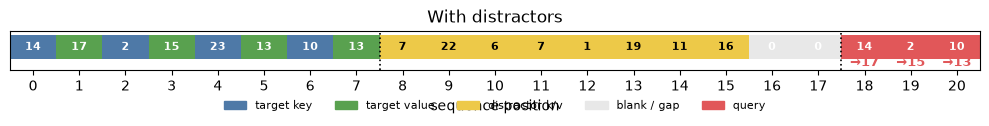

In [6]:
dp, dq, dgap, dvocab, ndist = 4, 3, 2, 24, 4
di, dt, dm = make_mqar(batch=4, n_pairs=dp, n_queries=dq, gap=dgap, vocab=dvocab,
                       seed=SEED, n_distractors=ndist)
Ld = di.shape[1]
ds_start = 2 * dp                       # distractor block start
dq_start = 2 * dp + 2 * ndist + dgap    # query block start
print(f"inputs {di.shape}   targets={dp} ({2*dp} tok) · distractors={ndist} ({2*ndist} tok) · "
      f"gap={dgap} · queries={dq}  ->  L={Ld}")
print("  target writes (queryable)        :",
      {int(di[0, 2*i]): int(di[0, 2*i+1]) for i in range(dp)})
print("  distractor writes (NEVER queried):",
      {int(di[0, ds_start+2*i]): int(di[0, ds_start+2*i+1]) for i in range(ndist)})

role = np.zeros(Ld, dtype=int)          # 0 blank,1 key,2 value,3 distractor,4 query
role[0:2*dp:2] = 1
role[1:2*dp:2] = 2
role[ds_start:ds_start+2*ndist] = 3
role[dq_start:dq_start+dq] = 4

cmap = ListedColormap(["#e8e8e8", "#4e79a7", "#59a14f", "#edc948", "#e15759"])
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 1.9))
ax.imshow(role[None, :], aspect="auto", cmap=cmap, norm=norm)
for t in range(Ld):
    ax.text(t, 0, str(int(di[0, t])), ha="center", va="center",
            color="black" if role[t] == 3 else "white", fontsize=8, fontweight="bold")
    if dm[0, t]:
        ax.text(t, 0.68, f"→{int(dt[0, t])}", ha="center", va="center",
                color="#e15759", fontsize=9, fontweight="bold")
ax.axvline(ds_start - 0.5, color="k", lw=1.2, ls=":")            # targets | distractors
ax.axvline(dq_start - 0.5, color="k", lw=1.2, ls=":")            # gap | queries
ax.set_ylim(1.0, -0.7); ax.set_yticks([]); ax.set_xticks(range(Ld))
ax.set_xlabel("sequence position")
ax.set_title("With distractors")
handles = [Patch(color="#4e79a7", label="target key"), Patch(color="#59a14f", label="target value"),
           Patch(color="#edc948", label="distractor k/v"), Patch(color="#e8e8e8", label="blank / gap"),
           Patch(color="#e15759", label="query")]
ax.legend(handles=handles, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.5),
          frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig("figures/03_distractor_data.png", dpi=600, bbox_inches="tight"); plt.show()

## Conventions (shared across A, B, C)

The same setup and reporting apply to all three; stated once here.

- Train once, test at every setting. Each section trains its own models on a mix of difficulties, then tests the frozen model at each setting. One model per (layer, CG, δ): they cannot share weights, since the forget setting and the solve depth change the model structurally.
- Forgetting matched. Both layers start at the same keep-rate δ, so the comparison is about capacity and algorithm, not the starting forget bias: Mesa via `mesa_retention_init = logit(δ)`, GDN via `gdn_retention_init = δ`. Both stay trainable.
- Compute is CG steps. CG=1 is about the cheap GLA read-out, CG toward 30 is the exact solve. Cost: Mesa at CG=k is about k times the GLA cost; GDN is about 1 times.
- Same scoring, via `mqar_exact_match` (answer tokens only).
- Stabilised training. Mesa's exact solve is touchy to optimise, so training uses gradient clipping and LR warmup by default; without them the high-CG models sometimes blow up.
- Reproducibility. The GPU kernels are not bit-exact, and CG=1 (and, less so, GDN) wobble seed to seed. The orderings are stable, the third decimal is not. Trust CG=2 and up.
- Small 2-layer models; needs a GPU.

## A · Capacity: where the exact solve should pay off

Notebooks 01 and 02 were regression. This is the recall test: write a set of key→value pairs into memory, then read them back. This is exactly where Mesa's "fit all of history" solve and its bigger state should earn their cost.

A confound to watch. Recall is where retention matters most, so the forget-gate starting bias (flagged in 01 and 02) matters most here. We therefore start both layers at the same keep-rate. If Mesa still lost here, that would signal something upstream is broken, since this is the task it should win.

### A · Design

Capacity sweep plus a control. Train one model per (layer, CG) on a mix of n_pairs and gap, then test per setting. Forgetting matched near 1 (δ about 0.982). See Conventions.

In [7]:
# ----- config (edit here) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 0

VOCAB        = 128                       # distinct keys live in [1, VOCAB); need VOCAB > max n_pairs
N_QUERIES    = 8                         # queries per sequence (also the depth axis for the position view)
TRAIN_PAIRS  = (2, 4, 8, 16, 32, 64)     # n_pairs mixed during training (memory load)
TRAIN_GAPS   = (2, 8, 16, 32)            # write->query gap mixed during training (retention)
STEPS        = 4000                      # Mesa converges slowly on recall -> a generous budget
                                         # (with grad-clip + warmup; see the stability caveat in the close)
CG_GRID      = [1, 2, 5, 10, 30]         # Mesa CG steps (test-time-compute dial)

# evaluation grids (evaluation-time only; the trained models_cap are frozen)
PAIRS_GRID   = [2, 4, 8, 16, 32, 64, 96] # capacity sweep: clearly under- to clearly over-loaded
GAP_GRID     = [2, 8, 16, 32, 64]        # gap (retention) sweep
GAP_FIXED    = 8                         # gap held during the capacity sweep
NPAIRS_GAP   = 32                        # n_pairs held during the gap sweep (already under pressure)
NPAIRS_HEAD  = 64                        # headline CG-overlay setting: capacity actually bites here
GAP_HEAD     = 8
NPAIRS_POS   = 32                        # position-resolved (depth) setting
GAP_POS      = 8

# effective key dimension (rough): per-head state is head_dim x head_dim
HEAD_DIM = 128 // 4
print(f"head_dim = {HEAD_DIM}  (num_heads=4, hidden=128)  ->  expect recall to collapse "
      f"as n_pairs approaches ~{HEAD_DIM}-{4*HEAD_DIM}")

# --- forgetting held EQUAL & near 1 (as in notebook 02) ---
MESA_RET    = 4.0
GDN_RET     = float(torch.sigmoid(torch.tensor(MESA_RET)))   # σ(4.0) ≈ 0.982 (matched decay)
RETAIN_BIAS = 8.0                                            # §1b control: σ(8) ≈ 0.99966 -> forgetting "off"
print(f"forgetting matched: Mesa bias={MESA_RET} -> decay σ(4.0)={GDN_RET:.3f} "
      f"(memory horizon ~{1/(1-GDN_RET):.0f} tokens) ; GDN pinned to {GDN_RET:.3f}")

cfg_cap = MQARConfig(
    vocab=VOCAB, n_queries=N_QUERIES, train_pairs=TRAIN_PAIRS, train_gaps=TRAIN_GAPS,
    steps=STEPS, hidden_size=128, num_heads=4, num_layers=2,
    eval_batches=8, device=DEVICE,
    mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET,
)   # lr / grad_clip / warmup use the stabilised MQARConfig defaults (2e-3, clip 1.0, warmup 200)

head_dim = 32  (num_heads=4, hidden=128)  ->  expect recall to collapse as n_pairs approaches ~32-128
forgetting matched: Mesa bias=4.0 -> decay σ(4.0)=0.982 (memory horizon ~56 tokens) ; GDN pinned to 0.982


### A · Train once (sweeps are test-only after this)

Train the full set, Mesa at CG in {1,2,5,10,30} plus GDN, six models, each on the mixed (n_pairs, gap) data. Training is the only slow step; every figure below reuses these frozen models. (Mesa's recall trains slowly, so this is the slowest cell.)

In [8]:
ALL_SPECS = [("mesa", k) for k in CG_GRID] + [("gated_deltanet", None)]
models_cap = train_mqar_models(ALL_SPECS, cfg_cap, seed=SEED)

print("trained models_cap (frozen, reused for every sweep):")
for lb, tm in models_cap.items():
    quick = tm.accuracy(4, GAP_FIXED)          # easy setting: should be ~1.0
    print(f"  {lb:16}  params={tm.num_params:,}  acc@(4 pairs)={quick:.3f}  dev={tm.device}")

# subset reused for the capacity / gap / position figures ("a couple of CG settings" + GDN)
cmp_cap = {lb: models_cap[lb] for lb in ["Mesa (CG=1)", "Mesa (CG=30)", "Gated DeltaNet"]}

/home/vzer/Documents/phd/linear_rnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


trained models_cap (frozen, reused for every sweep):
  Mesa (CG=1)       params=465,232  acc@(4 pairs)=0.990  dev=cuda
  Mesa (CG=2)       params=465,232  acc@(4 pairs)=0.993  dev=cuda
  Mesa (CG=5)       params=465,232  acc@(4 pairs)=0.991  dev=cuda
  Mesa (CG=10)      params=465,232  acc@(4 pairs)=0.991  dev=cuda
  Mesa (CG=30)      params=465,232  acc@(4 pairs)=0.994  dev=cuda
  Gated DeltaNet    params=466,000  acc@(4 pairs)=0.992  dev=cuda


### A1 · Capacity sweep: accuracy vs n_pairs (gap fixed)

Fix the gap, vary n_pairs from clearly light (2) to clearly overloaded (96).

In [9]:
cap_rows = mqar_sweep_rows(cmp_cap, "n_pairs", PAIRS_GRID, gap=GAP_FIXED, seed=SEED)
print(f"answer-token exact-match accuracy  (gap={GAP_FIXED}, vary n_pairs):")
show(cap_rows, "n_pairs")

answer-token exact-match accuracy  (gap=8, vary n_pairs):
         n_pairs       2       4       8      16      32      64      96
     Mesa (CG=1)   1.000   0.990   0.975   0.937   0.866   0.633   0.442
    Mesa (CG=30)   0.997   0.994   0.977   0.943   0.882   0.692   0.499
  Gated DeltaNet   1.000   0.992   0.972   0.902   0.673   0.361   0.222


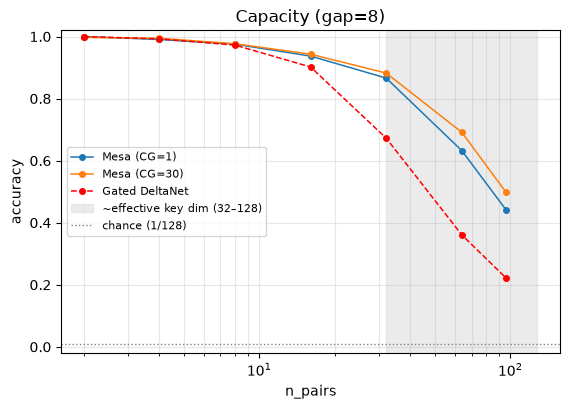

In [10]:
ax = plot_mse_vs(cap_rows, "n_pairs",
                 title=f"Capacity (gap={GAP_FIXED})",
                 xlabel="n_pairs",
                 ykey="acc", ylabel="accuracy",
                 logy=False, logx=True, lw=1.1)
ax.axvspan(HEAD_DIM, 4 * HEAD_DIM, color="0.85", alpha=0.5, zorder=0,
           label=f"~effective key dim ({HEAD_DIM}–{4*HEAD_DIM})")
ax.axhline(1.0 / VOCAB, color="gray", ls=":", lw=1, label=f"chance (1/{VOCAB})")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/03A_capacity.png", dpi=600, bbox_inches="tight"); plt.show()

### A1b · Capacity control: is it "state full" or "forgot the early ones"?

A1 ran at keep-rate δ about 0.98. That sounds like "barely forgets," but it compounds: over a write block of 100-plus tokens, the earliest pairs fade a lot. The memory horizon is about 1/(1-δ), roughly 56 tokens, or 28 pairs. That sits right on top of the state's capacity limit (about head_dim = 32), so the A1 drop could be the state running out of room, or the gate forgetting early writes. The two are tangled together.

This control re-runs the sweep with forgetting basically off (δ toward 1, horizon about 3000 tokens). If a model's drop moves to higher n_pairs with forgetting off, its A1 drop was partly forgetting; if the curve does not move, it is real capacity.

In [11]:
GDN_OFF = float(torch.sigmoid(torch.tensor(RETAIN_BIAS)))   # match GDN's initial decay to δ→1
cfg_cap_off = MQARConfig(
    vocab=VOCAB, n_queries=N_QUERIES, train_pairs=TRAIN_PAIRS, train_gaps=TRAIN_GAPS,
    steps=STEPS, hidden_size=128, num_heads=4, num_layers=2, eval_batches=8, device=DEVICE,
    mesa_retention_init=RETAIN_BIAS, gdn_retention_init=GDN_OFF,
)
print(f"forgetting OFF: Mesa bias={RETAIN_BIAS} -> decay σ={GDN_OFF:.5f} "
      f"(memory horizon ~{1/(1-GDN_OFF):.0f} tokens) ; GDN pinned to {GDN_OFF:.5f}")

# train the same 3-model subset with forgetting off (reuses cmp_cap's labels)
models_cap_off   = train_mqar_models([("mesa", 1), ("mesa", 30), ("gated_deltanet", None)],
                                 cfg_cap_off, seed=SEED)
cap_rows_off = mqar_sweep_rows(models_cap_off, "n_pairs", PAIRS_GRID, gap=GAP_FIXED, seed=SEED)
print(f"\naccuracy with forgetting OFF (gap={GAP_FIXED}, vary n_pairs):")
show(cap_rows_off, "n_pairs")

forgetting OFF: Mesa bias=8.0 -> decay σ=0.99966 (memory horizon ~2982 tokens) ; GDN pinned to 0.99966

accuracy with forgetting OFF (gap=8, vary n_pairs):
         n_pairs       2       4       8      16      32      64      96
     Mesa (CG=1)   1.000   0.990   0.968   0.871   0.587   0.316   0.205
    Mesa (CG=30)   1.000   0.993   0.978   0.946   0.887   0.674   0.462
  Gated DeltaNet   1.000   0.995   0.980   0.925   0.742   0.438   0.263


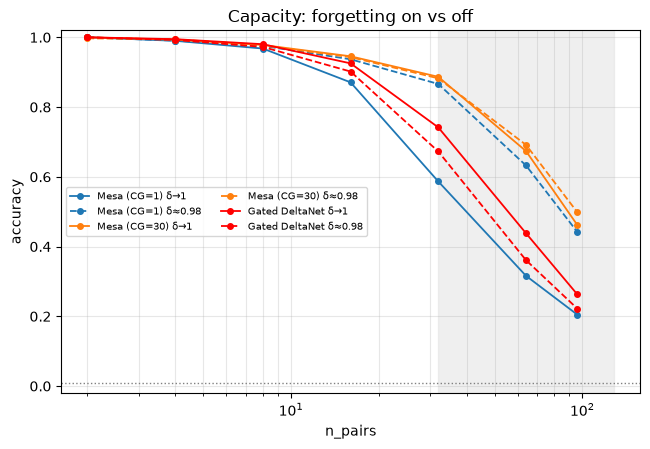

In [12]:
ax = plot_capacity_forget_control(
    cap_rows_off, cap_rows,
    xlabel="n_pairs",
    title="Capacity: forgetting on vs off")
ax.axvspan(HEAD_DIM, 4 * HEAD_DIM, color="0.85", alpha=0.4, zorder=0)
ax.axhline(1.0 / VOCAB, color="gray", ls=":", lw=1)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.savefig("figures/03A_capacity_control.png", dpi=600, bbox_inches="tight"); plt.show()

### A2 · Gap sweep: accuracy vs gap

Hold a moderate n_pairs and vary the write→query gap (blank filler tokens between writing and asking).

In [13]:
gap_rows = mqar_sweep_rows(cmp_cap, "gap", GAP_GRID, n_pairs=NPAIRS_GAP, seed=SEED)
print(f"answer-token exact-match accuracy  (n_pairs={NPAIRS_GAP}, vary gap):")
show(gap_rows, "gap")

answer-token exact-match accuracy  (n_pairs=32, vary gap):
             gap       2       8      16      32      64
     Mesa (CG=1)   0.865   0.866   0.866   0.862   0.854
    Mesa (CG=30)   0.881   0.882   0.882   0.882   0.882
  Gated DeltaNet   0.669   0.673   0.673   0.672   0.673


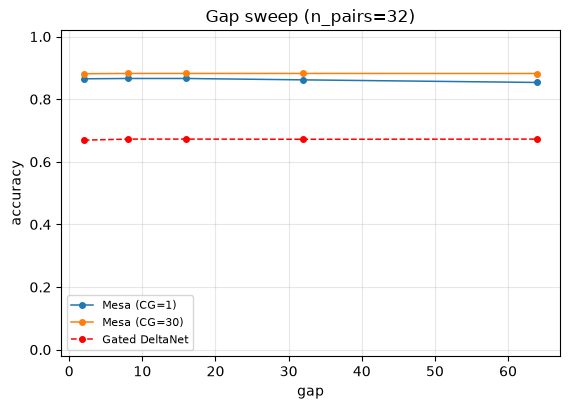

In [14]:
ax = plot_mse_vs(gap_rows, "gap",
                 title=f"Gap sweep (n_pairs={NPAIRS_GAP})",
                 xlabel="gap",
                 ykey="acc", ylabel="accuracy",
                 logy=False, lw=1.1)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/03A_gap.png", dpi=600, bbox_inches="tight"); plt.show()

### A3 · CG cost vs quality (headline)

The figure the suite builds toward: at a load where capacity actually bites, how does accuracy move as we spend more compute (Mesa CG steps)? GDN is the flat reference (no CG dial, cost about 1 times GLA). The annotation spells out the cost: each CG step is about one more GLA-equivalent pass.

In [15]:
cg_rows = mqar_cg_rows(models_cap, NPAIRS_HEAD, GAP_HEAD, seed=SEED)
print(f"answer-token exact-match accuracy  (n_pairs={NPAIRS_HEAD}, gap={GAP_HEAD}):")
show(cg_rows, "cg_steps")
gdn_ref = [r["acc"] for r in cg_rows if r["layer"] == "gated_deltanet"][0]
print(f"\nGDN reference accuracy = {gdn_ref:.3f}   |   {mqar_flops_note(30)}")

answer-token exact-match accuracy  (n_pairs=64, gap=8):
        cg_steps       1       2       5      10      30
     Mesa (CG=1)   0.633      --      --      --      --
     Mesa (CG=2)      --   0.663      --      --      --
     Mesa (CG=5)      --      --   0.668      --      --
    Mesa (CG=10)      --      --      --   0.688      --
    Mesa (CG=30)      --      --      --      --   0.692
  Gated DeltaNet      --      --      --      --      --

GDN reference accuracy = 0.361   |   Mesa(CG=30) ≈ 30× GLA mixer FLOPs  (GDN ≈ 1× GLA)


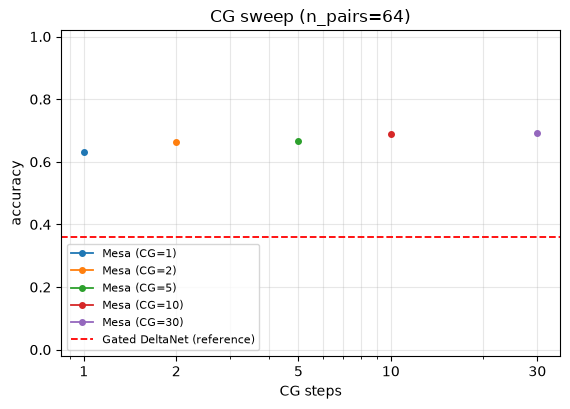

In [16]:
ax = plot_mse_vs(cg_rows, "cg_steps",
                 title=f"CG sweep (n_pairs={NPAIRS_HEAD})",
                 xlabel="CG steps",
                 ykey="acc", ylabel="accuracy",
                 logy=False, logx=True, lw=1.3, dim_alpha=1.0)
ax.set_xticks(CG_GRID); ax.set_xticklabels([str(c) for c in CG_GRID])
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/03A_cg_headline.png", dpi=600, bbox_inches="tight"); plt.show()

### A4 · Depth (per-query position)

A cheap depth probe with no extra length sweep: at one load, plot accuracy at each query position (1st query, 2nd, and so on). Later queries sit deeper past the writes, so this shows whether Mesa's edge grows with depth.

In [17]:
pos_rows = mqar_position_rows(cmp_cap, NPAIRS_POS, GAP_POS, n_queries=N_QUERIES, seed=SEED)
print(f"per-query-index accuracy  (n_pairs={NPAIRS_POS}, gap={GAP_POS}, {N_QUERIES} queries):")
show(pos_rows, "query_pos")

per-query-index accuracy  (n_pairs=32, gap=8, 8 queries):
       query_pos       1       2       3       4       5       6       7       8
     Mesa (CG=1)   0.857   0.852   0.865   0.869   0.871   0.865   0.889   0.861
    Mesa (CG=30)   0.875   0.869   0.875   0.865   0.893   0.881   0.916   0.885
  Gated DeltaNet   0.703   0.676   0.691   0.631   0.695   0.658   0.674   0.652


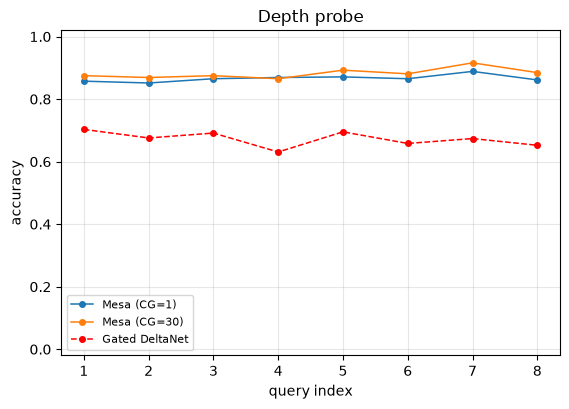

In [18]:
ax = plot_mse_vs(pos_rows, "query_pos",
                 title="Depth probe",
                 xlabel="query index",
                 ykey="acc", ylabel="accuracy",
                 logy=False, lw=1.1)
ax.set_xticks(range(1, N_QUERIES + 1))
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/03A_depth.png", dpi=600, bbox_inches="tight"); plt.show()

### A5 · Summary (computed)

A compact readout that does not depend on hardcoded numbers: the easy-regime tie, the Mesa vs GDN margin at high load, the best CG at the headline setting, and the depth trend.

In [19]:
def margin_at(rows, x, xv):
    d = {r["label"]: r["acc"] for r in rows if r.get(x) == xv}
    return d

easy = margin_at(cap_rows, "n_pairs", min(PAIRS_GRID))
hard = margin_at(cap_rows, "n_pairs", max(PAIRS_GRID))
print(f"(a) easy regime (n_pairs={min(PAIRS_GRID)}):  " +
      "  ".join(f"{k}={v:.2f}" for k, v in easy.items()))
print(f"    -> all near 1.0? {'YES' if all(v > 0.9 for v in easy.values()) else 'NO'}\n")

best_mesa_hard = max(v for k, v in hard.items() if k.startswith("Mesa"))
gdn_hard = hard.get("Gated DeltaNet", float('nan'))
print(f"(b) heavy load (n_pairs={max(PAIRS_GRID)}):  " +
      "  ".join(f"{k}={v:.2f}" for k, v in hard.items()))
print(f"    -> best Mesa − GDN margin = {best_mesa_hard - gdn_hard:+.2f}  "
      f"({'Mesa wins recall' if best_mesa_hard > gdn_hard else 'GDN wins - investigate!'})\n")

cg_acc = {r["cg_steps"]: r["acc"] for r in cg_rows if r["layer"] == "mesa"}
best_cg = max(cg_acc, key=cg_acc.get)
print(f"(c) headline (n_pairs={NPAIRS_HEAD}, gap={GAP_HEAD}):  "
      f"best Mesa CG = {best_cg} (acc {cg_acc[best_cg]:.2f});  "
      f"CG=1 {cg_acc.get(1, float('nan')):.2f}  CG=30 {cg_acc.get(30, float('nan')):.2f};  "
      f"GDN {gdn_ref:.2f}")
cg_gap = cg_acc.get(30, float("nan")) - cg_acc.get(1, float("nan"))
verdict = ("more CG clearly helps" if cg_gap > 0.05 else
           "more CG clearly hurts" if cg_gap < -0.05 else
           "within noise - CG>=1 already captures recall")
print(f"    -> CG dial (matched δ): {verdict}  (best CG={best_cg}; CG=30 - CG=1 = {cg_gap:+.2f})")

# control: did forgetting hide part of the high-load drop? (shift when delta -> 1)
print(f"\n(control) forgetting off vs matched, accuracy at n_pairs=64 (gap={GAP_FIXED}):")
ko = {r["label"]: r["acc"] for r in cap_rows if r["n_pairs"] == 64}
oo = {r["label"]: r["acc"] for r in cap_rows_off if r["n_pairs"] == 64}
for lb in ko:
    d = oo[lb] - ko[lb]
    if abs(d) < 0.03:
        tag = "(decay-robust: real capacity)"
    elif d > 0:
        tag = "(off > matched: its drop was partly forgetting)"
    else:
        tag = "(decay-sensitive but seed-unstable: off < matched here)"
    print(f"    {lb:16} matched {ko[lb]:.2f} -> off {oo[lb]:.2f}  ({d:+.2f})  {tag}")

pos_first = {r["label"]: r["acc"] for r in pos_rows if r["query_pos"] == 1}
pos_last  = {r["label"]: r["acc"] for r in pos_rows if r["query_pos"] == N_QUERIES}
print(f"\n(depth) query 1 -> query {N_QUERIES} accuracy change:")
for lb in pos_first:
    print(f"    {lb:16} {pos_first[lb]:.2f} -> {pos_last[lb]:.2f}  ({pos_last[lb]-pos_first[lb]:+.2f})")

(a) easy regime (n_pairs=2):  Mesa (CG=1)=1.00  Mesa (CG=30)=1.00  Gated DeltaNet=1.00
    -> all near 1.0? YES

(b) heavy load (n_pairs=96):  Mesa (CG=1)=0.44  Mesa (CG=30)=0.50  Gated DeltaNet=0.22
    -> best Mesa − GDN margin = +0.28  (Mesa wins recall)

(c) headline (n_pairs=64, gap=8):  best Mesa CG = 30 (acc 0.69);  CG=1 0.63  CG=30 0.69;  GDN 0.36
    -> CG dial (matched δ): more CG clearly helps  (best CG=30; CG=30 - CG=1 = +0.06)

(control) forgetting off vs matched, accuracy at n_pairs=64 (gap=8):
    Mesa (CG=1)      matched 0.63 -> off 0.32  (-0.32)  (decay-sensitive but seed-unstable: off < matched here)
    Mesa (CG=30)     matched 0.69 -> off 0.67  (-0.02)  (decay-robust: real capacity)
    Gated DeltaNet   matched 0.36 -> off 0.44  (+0.08)  (off > matched: its drop was partly forgetting)

(depth) query 1 -> query 8 accuracy change:
    Mesa (CG=1)      0.86 -> 0.86  (+0.00)
    Mesa (CG=30)     0.88 -> 0.88  (+0.01)
    Gated DeltaNet   0.70 -> 0.65  (-0.05)


## B · Distractors: interference and the forget gate

Section A used a blank gap (no competing information). Here we fill the gap with distractors: extra key→value pairs that are never asked about, with keys different from the targets, written after the targets so they are the most recent memories before the questions. That turns "distance" into real interference. Because the distractors are newer than the targets, forgetting now matters: a recency-biased state keeps the distractors and loses the older targets.

This is also the concrete answer to "where on recall should I sweep the forget gate?": here, since distractors are what finally give it teeth.

### B · Design

Distractors are never-asked key→value pairs (different keys from the targets) written after the targets, via `make_mqar(..., n_distractors=k)`; training mixes the count. Clean baseline: n_pairs and gap small, so any drop is due to the distractors. B1 keeps forgetting matched near 1; B2 sweeps δ (retraining per δ). See Conventions.

In [20]:
# ----- config (edit here) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 0

VOCAB        = 128
N_QUERIES    = 4
NPAIRS       = 8                         # fixed target load (clean baseline ~1.0 with 0 distractors)
GAP          = 2                         # small blank gap (distance alone was flat in 03)
TRAIN_DIST   = (0, 8, 16, 32, 64)        # distractor counts mixed during training
DIST_GRID    = [0, 8, 16, 32, 64]        # distractor sweep (eval-time)
STEPS        = 3000

# §2 forget sweep
DELTA_GRID   = [0.5, 0.8, 0.95, 0.99]    # shared initial decay δ (1 = retain everything)
ND_FIXED     = 16                        # distractor load held during the δ sweep

# forgetting matched near 1 for §1 (as in 02/03)
MESA_RET = 4.0
GDN_RET  = float(torch.sigmoid(torch.tensor(MESA_RET)))   # σ(4.0) ≈ 0.982
print(f"base: n_pairs={NPAIRS}, gap={GAP}, vocab={VOCAB}; forgetting matched δ≈{GDN_RET:.3f}")

cfg_dist = MQARConfig(
    vocab=VOCAB, n_queries=N_QUERIES, train_pairs=(NPAIRS,), train_gaps=(GAP,),
    train_distractors=TRAIN_DIST, steps=STEPS, hidden_size=128, num_heads=4, num_layers=2,
    eval_batches=8, device=DEVICE, mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET,
)

base: n_pairs=8, gap=2, vocab=128; forgetting matched δ≈0.982


### B1 · Distractor sweep

Train Mesa (CG=1 and CG=30) and GDN with distractors mixed in, then vary the number of distractors at the fixed clean base.

In [21]:
models_dist = train_mqar_models([("mesa", 1), ("mesa", 30), ("gated_deltanet", None)], cfg_dist, seed=SEED)
print("trained (frozen):")
for lb, tm in models_dist.items():
    print(f"  {lb:16}  params={tm.num_params:,}  acc@(0 distractors)={tm.accuracy(NPAIRS, GAP, n_distractors=0):.3f}")

dist_rows = mqar_sweep_rows(models_dist, "n_distractors", DIST_GRID, n_pairs=NPAIRS, gap=GAP, seed=SEED)
print(f"\nanswer-token exact-match accuracy  (n_pairs={NPAIRS}, gap={GAP}, vary n_distractors):")
show(dist_rows, "n_distractors")

trained (frozen):
  Mesa (CG=1)       params=465,232  acc@(0 distractors)=0.935
  Mesa (CG=30)      params=465,232  acc@(0 distractors)=0.974
  Gated DeltaNet    params=466,000  acc@(0 distractors)=0.483

answer-token exact-match accuracy  (n_pairs=8, gap=2, vary n_distractors):
   n_distractors       0       8      16      32      64
     Mesa (CG=1)   0.935   0.901   0.887   0.876   0.850
    Mesa (CG=30)   0.974   0.966   0.959   0.963   0.964
  Gated DeltaNet   0.483   0.481   0.474   0.469   0.482


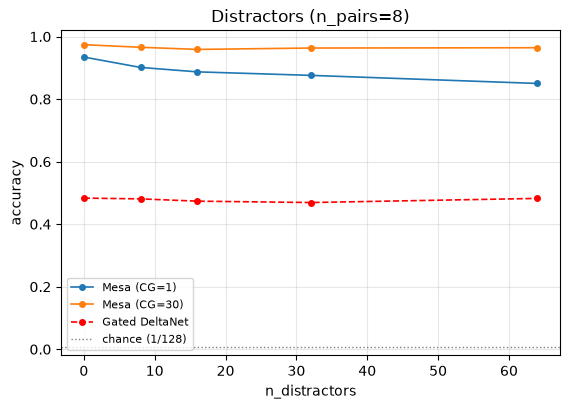

In [22]:
ax = plot_mse_vs(dist_rows, "n_distractors",
                 title=f"Distractors (n_pairs={NPAIRS})",
                 xlabel="n_distractors",
                 ykey="acc", ylabel="accuracy",
                 logy=False, lw=1.2, dim_alpha=1.0)
ax.axhline(1.0 / VOCAB, color="gray", ls=":", lw=1, label=f"chance (1/{VOCAB})")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/03B_distractors.png", dpi=600, bbox_inches="tight"); plt.show()

### B2 · Forget gate × distractors

Now sweep the shared keep-rate δ for both layers at a fixed distractor load, retraining per δ. The x-axis is the forget rate 1-δ (left = forget fast, right = keep everything).

In [23]:
fgt_rows = []
for delta in DELTA_GRID:
    bias = math.log(delta / (1.0 - delta))     # logit(δ) -> Mesa decay-gate bias
    cfg_d = MQARConfig(
        vocab=VOCAB, n_queries=N_QUERIES, train_pairs=(NPAIRS,), train_gaps=(GAP,),
        train_distractors=TRAIN_DIST, steps=STEPS, hidden_size=128, num_heads=4, num_layers=2,
        eval_batches=8, device=DEVICE, mesa_retention_init=bias, gdn_retention_init=float(delta),
    )
    for layer, cg in [("mesa", 30), ("gated_deltanet", None)]:
        tm = train_mqar(layer, cg, cfg_d, seed=SEED)
        acc = tm.accuracy(NPAIRS, GAP, n_distractors=ND_FIXED, seed=SEED)
        fgt_rows.append({"label": tm.label, "layer": tm.layer, "cg_steps": tm.cg_steps,
                         "delta": float(delta), "forget_rate": round(1.0 - delta, 4), "acc": acc})

print(f"accuracy vs forget rate  (n_pairs={NPAIRS}, gap={GAP}, n_distractors={ND_FIXED}):")
show(fgt_rows, "forget_rate")

accuracy vs forget rate  (n_pairs=8, gap=2, n_distractors=16):
     forget_rate    0.01    0.05     0.2     0.5
    Mesa (CG=30)   0.960   0.876   0.008   0.028
  Gated DeltaNet   0.484   0.734   0.034   0.010


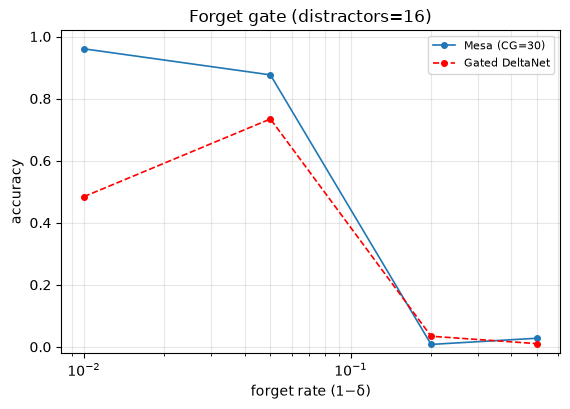

In [24]:
ax = plot_mse_vs(fgt_rows, "forget_rate",
                 title=f"Forget gate (distractors={ND_FIXED})",
                 xlabel="forget rate (1−δ)",
                 ykey="acc", ylabel="accuracy",
                 logy=False, logx=True, lw=1.2, dim_alpha=1.0)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/03B_forget.png", dpi=600, bbox_inches="tight"); plt.show()

## C · δ × CG: do Mesa's two knobs interact?

We have studied Mesa's two knobs separately: the forget gate δ (how much it keeps; 02 and section B) and the solve depth CG (how hard it solves; section A). This section maps their joint surface on the task where each one matters strongly, distractor recall (section B), and asks whether they are independent or interact.

Why this task: here both knobs work on the same problem, keeping the older targets readable through the newer distractors. Drift (02) has δ effects too, but probably independent ones; distractor recall is where they might genuinely interact.

### C · Design

The joint δ-by-CG grid on the fixed section B distractor setting (same n_pairs, gap, n_distractors, where CG=30 and CG=1 separated). One model per (δ, CG) cell: 6 δ by 5 CG is 30 Mesa, plus 6 GDN, for 36 trainings. This is the most expensive experiment in the suite, so the config cell prints the cell count and a time estimate, letting you pick the per-cell budget before running. See Conventions.

In [25]:
# ----- config (edit here) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 0

# fixed distractor-MQAR setting (reused verbatim from 04's δ-sweep slice)
VOCAB, N_QUERIES   = 128, 4
NPAIRS, GAP        = 8, 2
N_DISTRACTORS      = 16                       # interference bites here; CG=30 robust / CG=1 sensitive in 04
TRAIN_DIST         = (0, 8, 16, 32, 64)       # distractor counts mixed during training (as 04)

# the 2-D grid
DELTA_GRID         = [0.5, 0.8, 0.9, 0.95, 0.98, 1.0]   # initial decay δ (1 = retain everything)
CG_GRID            = [1, 2, 5, 10, 30]                  # Mesa solve depth

# per-cell training budget (the lever to tune for total cost)
PER_CELL_STEPS     = 3000                     # 04 used 3000/point; lower = cheaper, shape still readable

cfg_dxcg = MQARConfig(
    vocab=VOCAB, n_queries=N_QUERIES, train_pairs=(NPAIRS,), train_gaps=(GAP,),
    train_distractors=TRAIN_DIST, steps=PER_CELL_STEPS, hidden_size=128, num_heads=4,
    num_layers=2, eval_batches=8, device=DEVICE,
)   # δ is set per cell by the sweep; lr/grad_clip/warmup use the stabilised MQARConfig defaults

# ----- compute estimate (surfaced BEFORE the sweep) -----
N_MESA = len(DELTA_GRID) * len(CG_GRID)
N_GDN  = len(DELTA_GRID)
N_CELLS = N_MESA + N_GDN
SEC_PER_1K = 15.0                             # calibration: 04 measured ~43s/model @ 3000 steps
est_min = N_CELLS * (PER_CELL_STEPS / 1000.0) * SEC_PER_1K / 60.0
print(f"grid: {len(DELTA_GRID)} δ × {len(CG_GRID)} CG = {N_MESA} Mesa + {N_GDN} GDN = {N_CELLS} trained models")
print(f"per-cell steps = {PER_CELL_STEPS}")
print(f"estimated wall-clock ≈ {est_min:.0f} min on this GPU  (~{est_min*60/N_CELLS:.0f}s/cell; CG=30 cells run slower)")
print(f"fixed setting: n_pairs={NPAIRS}, gap={GAP}, n_distractors={N_DISTRACTORS}, vocab={VOCAB}")

grid: 6 δ × 5 CG = 30 Mesa + 6 GDN = 36 trained models
per-cell steps = 3000
estimated wall-clock ≈ 27 min on this GPU  (~45s/cell; CG=30 cells run slower)
fixed setting: n_pairs=8, gap=2, n_distractors=16, vocab=128


### C · Run the sweep (expensive)

Warning: trains all 36 models. Check the printed estimate above and adjust `PER_CELL_STEPS` before running. Each cell trains one model on the distractor data and scores it at the fixed distractor load.

In [26]:
rows = mqar_delta_cg_sweep(
    DELTA_GRID, CG_GRID, cfg_dxcg,
    n_pairs=NPAIRS, gap=GAP, n_distractors=N_DISTRACTORS, seed=SEED, with_gdn=True,
)

# compact table: Mesa accuracy, rows = CG, cols = δ
mesa = [r for r in rows if r["layer"] == "mesa"]
cgs  = sorted({r["cg_steps"] for r in mesa})
print(f"Mesa accuracy  (n_pairs={NPAIRS}, gap={GAP}, n_distractors={N_DISTRACTORS}):")
print("   CG \\ δ   " + "  ".join(f"{d:>5g}" for d in DELTA_GRID))
for cg in cgs:
    line = {r["delta"]: r["acc"] for r in mesa if r["cg_steps"] == cg}
    print(f"   {cg:>5}   " + "  ".join(f"{line[d]:5.2f}" for d in DELTA_GRID))
gdn = {r["delta"]: r["acc"] for r in rows if r["layer"] == "gated_deltanet"}
print("   GDN     " + "  ".join(f"{gdn[d]:5.2f}" for d in DELTA_GRID))

Mesa accuracy  (n_pairs=8, gap=2, n_distractors=16):
   CG \ δ     0.5    0.8    0.9   0.95   0.98      1
       1    0.01   0.01   0.04   0.42   0.94   0.94
       2    0.01   0.01   0.78   0.88   0.88   0.96
       5    0.01   0.02   0.05   0.93   0.94   0.97
      10    0.01   0.01   0.89   0.94   0.95   0.96
      30    0.02   0.04   0.95   0.92   0.97   0.95
   GDN      0.01   0.02   0.01   0.52   0.80   0.84


### C1 · Heatmap (headline)

Accuracy over the δ × CG grid. GDN's best-δ score is noted for scale.

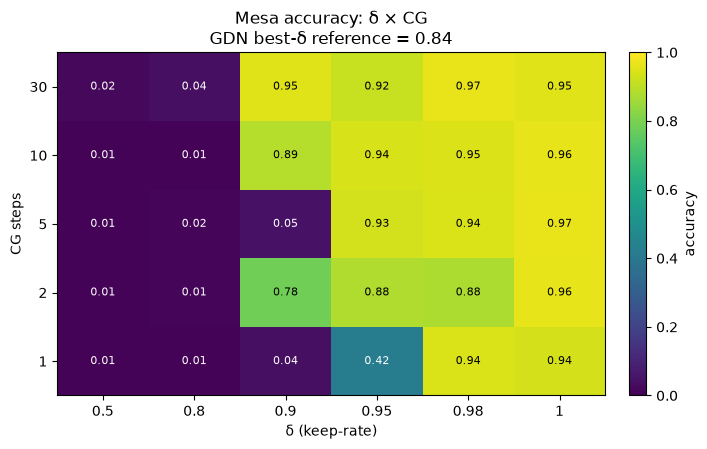

In [27]:
ax = plot_delta_cg_heatmap(rows,
        title="Mesa accuracy: δ × CG")
plt.tight_layout(); plt.savefig("figures/03C_heatmap.png", dpi=600, bbox_inches="tight"); plt.show()

### C2 · Line plots

The same data, two readable slices. Left: does the best δ shift with CG? Right: does the CG plateau height depend on δ?

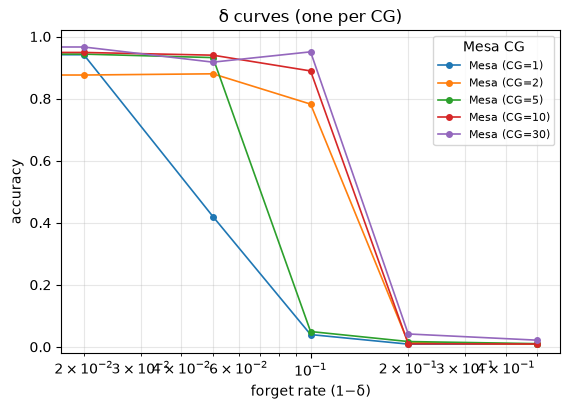

In [28]:
# δ-curves: one line per CG (x = forget rate 1−δ, log; left = aggressive forgetting)
ax = plot_mse_vs(mesa, "forget_rate",
                 title="δ curves (one per CG)",
                 xlabel="forget rate (1−δ)",
                 ykey="acc", ylabel="accuracy",
                 logy=False, logx=True, lw=1.2, dim_alpha=1.0)
ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8, title="Mesa CG")
plt.tight_layout(); plt.savefig("figures/03C_delta_curves.png", dpi=600, bbox_inches="tight"); plt.show()

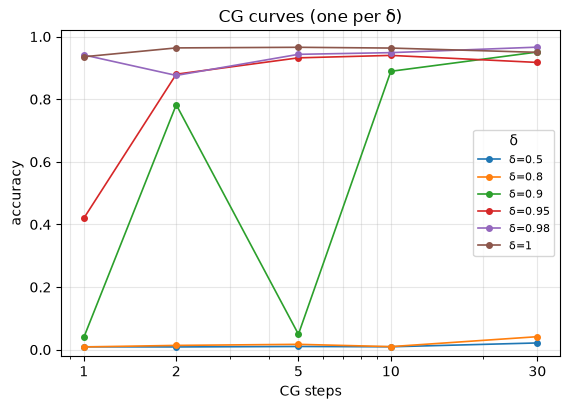

In [29]:
# CG-curves: one line per δ (relabel so plot_mse_vs groups by δ)
cg_view = [{**r, "label": f"δ={r['delta']:g}", "cg_steps_x": r["cg_steps"]} for r in mesa]
ax = plot_mse_vs(cg_view, "cg_steps_x",
                 title="CG curves (one per δ)",
                 xlabel="CG steps",
                 ykey="acc", ylabel="accuracy",
                 logy=False, logx=True, lw=1.2, dim_alpha=1.0)
ax.set_xticks(CG_GRID); ax.set_xticklabels([str(c) for c in CG_GRID])
ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8, title="δ")
plt.tight_layout(); plt.savefig("figures/03C_cg_curves.png", dpi=600, bbox_inches="tight"); plt.show()

### C · CG=1 caveat

CG=1 is forgetting-sensitive and seed-variable (see Conventions), so its row may look noisy across δ. Base the independent-vs-interact call on the CG=2-and-up rows; do not over-read the CG=1 row.

### C3 · Verdict (computed)

For each CG=2-and-up row, find the δ with the best accuracy (call it δ-star). If δ-star is about the same across CG, the knobs are independent. If δ-star shifts with CG, they interact.

In [30]:
def best_delta_per_cg(mesa_rows, cg_min=2):
    out = {}
    for cg in sorted({r["cg_steps"] for r in mesa_rows}):
        if cg < cg_min:
            continue
        cells = [r for r in mesa_rows if r["cg_steps"] == cg]
        best = max(cells, key=lambda r: r["acc"])
        out[cg] = (best["delta"], best["acc"])
    return out

bd = best_delta_per_cg(mesa, cg_min=2)
print("argmax-δ per CG (CG≥2, CG=1 excluded as unreliable):")
for cg, (d, a) in bd.items():
    print(f"   CG={cg:>2}:  δ* = {d:g}   (acc {a:.2f})")
deltas_star = [d for d, _ in bd.values()]
spread = max(deltas_star) - min(deltas_star)
print(f"\nδ* spread across CG = {spread:g}")
print("verdict:", "SEPARABLE (A) - δ* ~constant in CG" if spread <= 0.05 else
      "INTERACTIVE (B) - δ* shifts with CG")
# decay-sensitivity per CG: accuracy drop from best-δ to δ=0.5 (aggressive forgetting)
print("\ndecay sensitivity (best-δ acc − δ=0.5 acc), per CG:")
for cg in sorted({r["cg_steps"] for r in mesa}):
    cells = {r["delta"]: r["acc"] for r in mesa if r["cg_steps"] == cg}
    drop = max(cells.values()) - cells.get(0.5, float("nan"))
    print(f"   CG={cg:>2}:  Δ = {drop:+.2f}   ({'robust' if drop < 0.1 else 'sensitive'})")

argmax-δ per CG (CG≥2, CG=1 excluded as unreliable):
   CG= 2:  δ* = 1   (acc 0.96)
   CG= 5:  δ* = 1   (acc 0.97)
   CG=10:  δ* = 1   (acc 0.96)
   CG=30:  δ* = 0.98   (acc 0.97)

δ* spread across CG = 0.02
verdict: SEPARABLE (A) - δ* ~constant in CG

decay sensitivity (best-δ acc − δ=0.5 acc), per CG:
   CG= 1:  Δ = +0.93   (sensitive)
   CG= 2:  Δ = +0.96   (sensitive)
   CG= 5:  Δ = +0.96   (sensitive)
   CG=10:  Δ = +0.95   (sensitive)
   CG=30:  Δ = +0.94   (sensitive)
